In [41]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
    print(f.keys())

    R = f["R3"]
    print(R.keys())
    print(R["wall"].keys())
    print(R["wall"]["tau_mean_a"])
    print(f["R3"]["t"][:5])
    print(f["R13"]["t"][:5])

<KeysViewHDF5 ['R13', 'R14', 'R15', 'R18', 'R19', 'R21', 'R22', 'R23', 'R26', 'R28', 'R3', 'R4', 'R5', 'Ubase_laminar', 'Ubase_periodic_mean', 'readme', 'x', 'y', 'z']>
<KeysViewHDF5 ['is_turbulent', 'p_rapid', 'p_slow', 'p_stokes', 'p_total', 't', 'u', 'v', 'w', 'wall']>
<KeysViewHDF5 ['dudy_a', 'dudy_b', 'dwdy_a', 'dwdy_b', 'p_rapid_a', 'p_rapid_b', 'p_slow_a', 'p_slow_b', 'p_stokes_a', 'p_stokes_b', 'p_total_a', 'p_total_b', 'tau_mean_a', 'tau_mean_b']>
<HDF5 dataset "tau_mean_a": shape (4801,), type "<f4">
[200. 201. 202. 203. 204.]
[208. 224. 240. 256. 272.]


In [35]:
keys = 'u', 'v', 'w', 'p_total'
def extract(real, keys):
    data = []
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data.append(np.array(f[real][k]))
        return np.stack(data, axis=1)

In [36]:
d = extract('R3', keys)

In [37]:
d.shape

(4801, 4, 24, 33, 24)

In [40]:
d_hat = np.fft.fft2(d[::100], axes=(2, 4))

In [101]:
# check
_m = d[::100].sum(axis=(2, 4), keepdims=True)
_m.shape

(49, 4, 1, 33, 1)

In [102]:
np.abs(_m - d_hat[:, :, 0, :, 0][:, :, None, :, None]).max()

np.float32(6.1035156e-05)

In [139]:
means = d.mean(axis=(0, 2, 4), keepdims=True)

In [140]:
means.shape

(1, 4, 1, 33, 1)

In [141]:
flucts = d[::100] - means

In [142]:
d_hat.shape

(49, 4, 24, 33, 24)

In [143]:
d_flucts_hat = np.fft.fft2(flucts, axes=(2, 4))

In [144]:
mean_power = np.abs(d_hat[:, 0, :, 1, :].mean((0))) ** 2

In [145]:
def plot_powers(mean_power):
    shifted = np.fft.fftshift(mean_power)   # reorders so zero-frequency is centered
    
    plt.imshow(np.log10(shifted + 1e-20), origin='lower', cmap='viridis')
    plt.colorbar(label='log10(power)')
    plt.xlabel('kz index')
    plt.ylabel('kx index')
    plt.show()

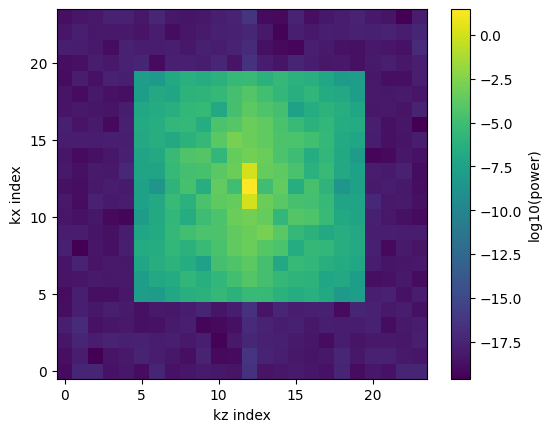

In [146]:
plot_powers(mean_power)

In [147]:
flucts_mean_power = np.abs(d_flucts_hat[:, 0, :, 1, :].mean((0))) ** 2

In [148]:
flucts_mean_power.max()

np.float32(1.1649277)

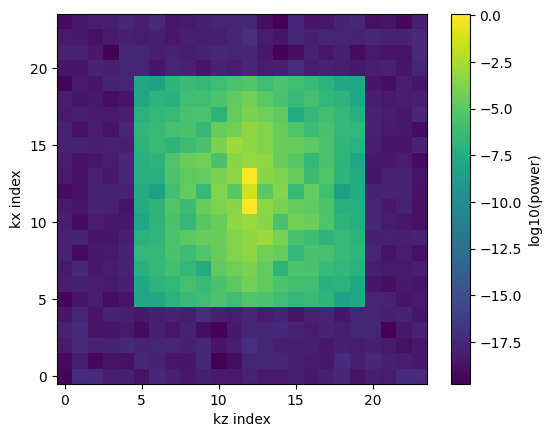

In [149]:
plot_powers(flucts_mean_power)

In [150]:
def domain():
    data = {}
    keys = ['x', 'y', 'z']
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data[k] = np.array(f[k])
        return data

In [151]:
domain = domain()

In [168]:
dx = domain['x'][1] - domain['x'][0]
dz = domain['z'][1] - domain['z'][0]
nx = domain['x'].shape[0]
nz = domain['z'].shape[0]
kx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2*np.pi
kz = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2*np.pi

In [153]:

def energy_per_scale(mean_power):
    kx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2*np.pi
    kz = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2*np.pi
    KX, KZ = np.meshgrid(kx, kz, indexing='ij')
    K = np.sqrt(KX**2 + KZ**2)
    
    power_shifted = np.fft.fftshift(mean_power)
    
    # bin into radial shells
    k_bins = np.linspace(0, K.max(), 20)
    radial_power = np.zeros(len(k_bins)-1)
    for i in range(len(k_bins)-1):
        mask = (K >= k_bins[i]) & (K < k_bins[i+1])
        radial_power[i] = power_shifted[mask].mean() if mask.any() else 0
    
    plt.plot(k_bins[:-1], radial_power)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('|k|')
    plt.ylabel('mean power')
    plt.show()

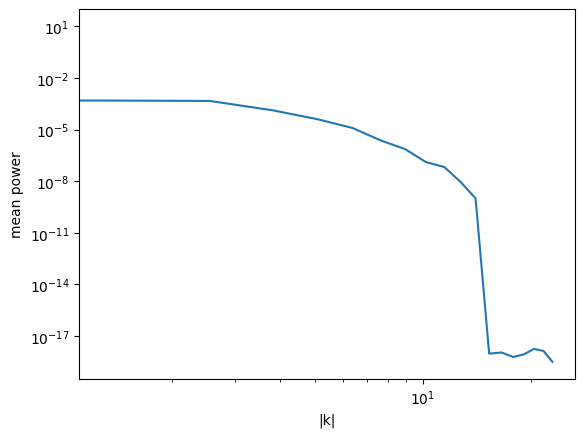

In [154]:
energy_per_scale(mean_power)

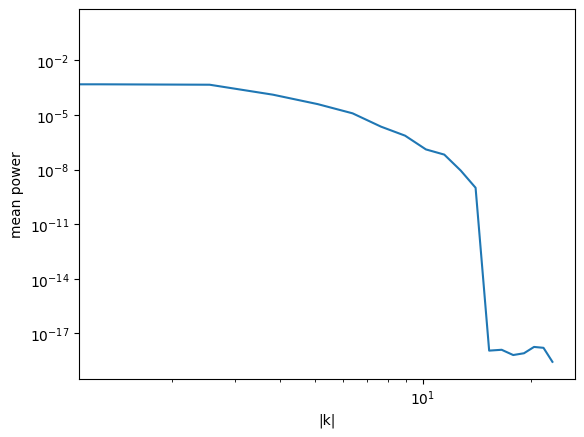

In [155]:
energy_per_scale(flucts_mean_power)

In [156]:
# ⟨p* . u⟩ - ⟨p⟩* . ⟨u⟩
# u, p of shape (...T, k...)
def cross_spectrum(p_hat, u_hat, avg_axis=(0,)):
    return np.mean(p_hat.conj() * u_hat, axis=avg_axis) - (np.mean(p_hat, axis=avg_axis).conj() * np.mean(u_hat, axis=avg_axis))
    
# coherence gamma2
# |Suu|2 / [ Spp Spu ]
def compute_coherence(p_hat, u_hat):
    Suu = cross_spectrum(u_hat, u_hat)
    Spu = cross_spectrum(p_hat, u_hat)
    Spp = cross_spectrum(p_hat, p_hat)

    return np.abs(Spu) ** 2 / (Suu * Spp)
    

In [157]:
pressure_hat = d_flucts_hat[:, 3, :, :, :]
coherence = compute_coherence(pressure_hat[:, :, 0, :][:, None, :, None, :], d_flucts_hat[:, :, :, 1:-1, :])

In [158]:
coherence.shape

(4, 24, 31, 24)

In [159]:
coherence.imag.sum()

np.float32(-6.80742e-07)

In [165]:
gamma2 = coherence.real

In [162]:
domain['y']

array([-1.00000000e+00, -9.95184727e-01, -9.80785280e-01, -9.56940336e-01,
       -9.23879533e-01, -8.81921264e-01, -8.31469612e-01, -7.73010453e-01,
       -7.07106781e-01, -6.34393284e-01, -5.55570233e-01, -4.71396737e-01,
       -3.82683432e-01, -2.90284677e-01, -1.95090322e-01, -9.80171403e-02,
        6.12323400e-17,  9.80171403e-02,  1.95090322e-01,  2.90284677e-01,
        3.82683432e-01,  4.71396737e-01,  5.55570233e-01,  6.34393284e-01,
        7.07106781e-01,  7.73010453e-01,  8.31469612e-01,  8.81921264e-01,
        9.23879533e-01,  9.56940336e-01,  9.80785280e-01,  9.95184727e-01,
        1.00000000e+00])

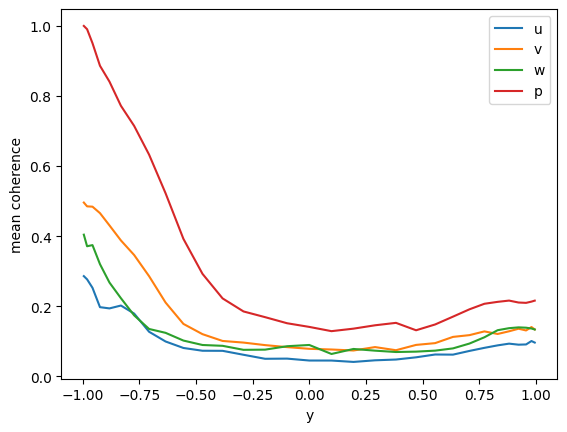

In [166]:
import matplotlib.pyplot as plt

y = domain['y'][1:-1]  # your wall-normal coordinate array, length 31, matching gamma2's y axis
comp_names = ['u', 'v', 'w', 'p']  # adjust to match your actual component ordering

fig, ax = plt.subplots()
for i, name in enumerate(comp_names):
    coh_y = gamma2[i].mean(axis=(0, 2))  # mean over kx, kz -> shape (y,)
    ax.plot(y, coh_y, label=name)

ax.set_xlabel('y')
ax.set_ylabel('mean coherence')
ax.legend()
plt.show()

In [167]:
def plot_coherence_map(gamma2, comp_idx, y_idx, kx_freqs, kz_freqs, comp_name=''):
    data = gamma2[comp_idx, :, y_idx, :]           # shape (kx, kz)
    data_shifted = np.fft.fftshift(data, axes=(0, 1))
    kx_shifted = np.fft.fftshift(kx_freqs)
    kz_shifted = np.fft.fftshift(kz_freqs)

    plt.imshow(data_shifted, origin='lower', vmin=0, vmax=1, cmap='viridis',
               extent=[kz_shifted[0], kz_shifted[-1], kx_shifted[0], kx_shifted[-1]])
    plt.colorbar(label='coherence')
    plt.xlabel('kz'); plt.ylabel('kx')
    plt.title(f'{comp_name}, y_idx={y_idx}')
    plt.show()

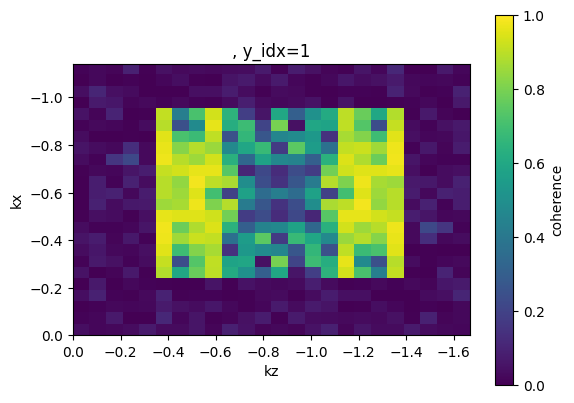

In [169]:
plot_coherence_map(gamma2, 0, 1, kx, kz)